# Pipeline Tag Prediction
## EDA on Untagged Model Card Predictions

**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook explores `untagged_model_cards_predicted.parquet`, the set of model cards that never had a `pipeline_tag` on the Hub, now tagged by the baseline model.

There is no ground truth label in this file, so we can't measure literal accuracy here. Instead we use `confidence_pct` as a proxy for how sure the model is about each prediction, and look at where that confidence is high, where it's shaky, and what that says about which tags are handled well versus poorly.

Steps:
1. Load the predicted dataset
2. Overall confidence distribution
3. Confidence by predicted tag
4. Predicted tag counts vs training distribution
5. Lowest confidence predictions per tag
6. Text length vs confidence
7. Summary table

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded')

Libraries loaded


## 1. Load Predicted Dataset

Loading `untagged_model_cards_predicted.parquet` from Drive. Columns: `modelId`, `card_text_clean`, `predicted_tag`, `confidence_pct`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/266-pipeline-tag-prediction'
df = pd.read_parquet(f'{DRIVE_DIR}/untagged_model_cards_predicted.parquet')

print(f'Shape: {df.shape}')
df.head()

Mounted at /content/drive
Shape: (115620, 4)


,modelId,card_text_clean,predicted_tag,confidence_pct
0,DreadPoor/Kitsch_Late_ALT-TEST-Q5_K_M-GGUF,dreadpoor kitsch late alt test q k m gguf imag...,image-text-to-text,42.78
1,namlevan888/blockassist-bc-lethal_durable_rave...,gensyn blockassist gensyn s blockassist is a d...,text-generation,30.50
2,ElenaSenger/career-path-representation-mpnet-d...,career path representation mpnet decorte this ...,sentence-similarity,87.87
3,priorcomputers/llama-3.2-1b-instruct-cn-dat-kr...,llama b instruct cn dat kr a creative this is ...,text-generation,97.08
4,mradermacher/ACC-Qwen3-30B-A3B-i1-GGUF,about quantize version output tensor quantised...,text-generation,43.50


In [3]:
df.info()
print()
print(df['confidence_pct'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115620 entries, 0 to 115619
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   modelId          115620 non-null  object 
 1   card_text_clean  115620 non-null  object 
 2   predicted_tag    115620 non-null  object 
 3   confidence_pct   115620 non-null  float64
dtypes: float64(1), object(3)
memory usage: 3.5+ MB

count    115620.000000
mean         63.595837
std          24.901461
min          14.140000
25%          39.810000
50%          64.090000
75%          88.360000
max         100.000000
Name: confidence_pct, dtype: float64


## 2. Overall Confidence Distribution

A first look at how confident the model is across all predictions, before splitting by tag. A distribution bunched near 100 means the model is mostly sure of itself on this population. A long left tail means a meaningful chunk of cards are genuinely hard to place.

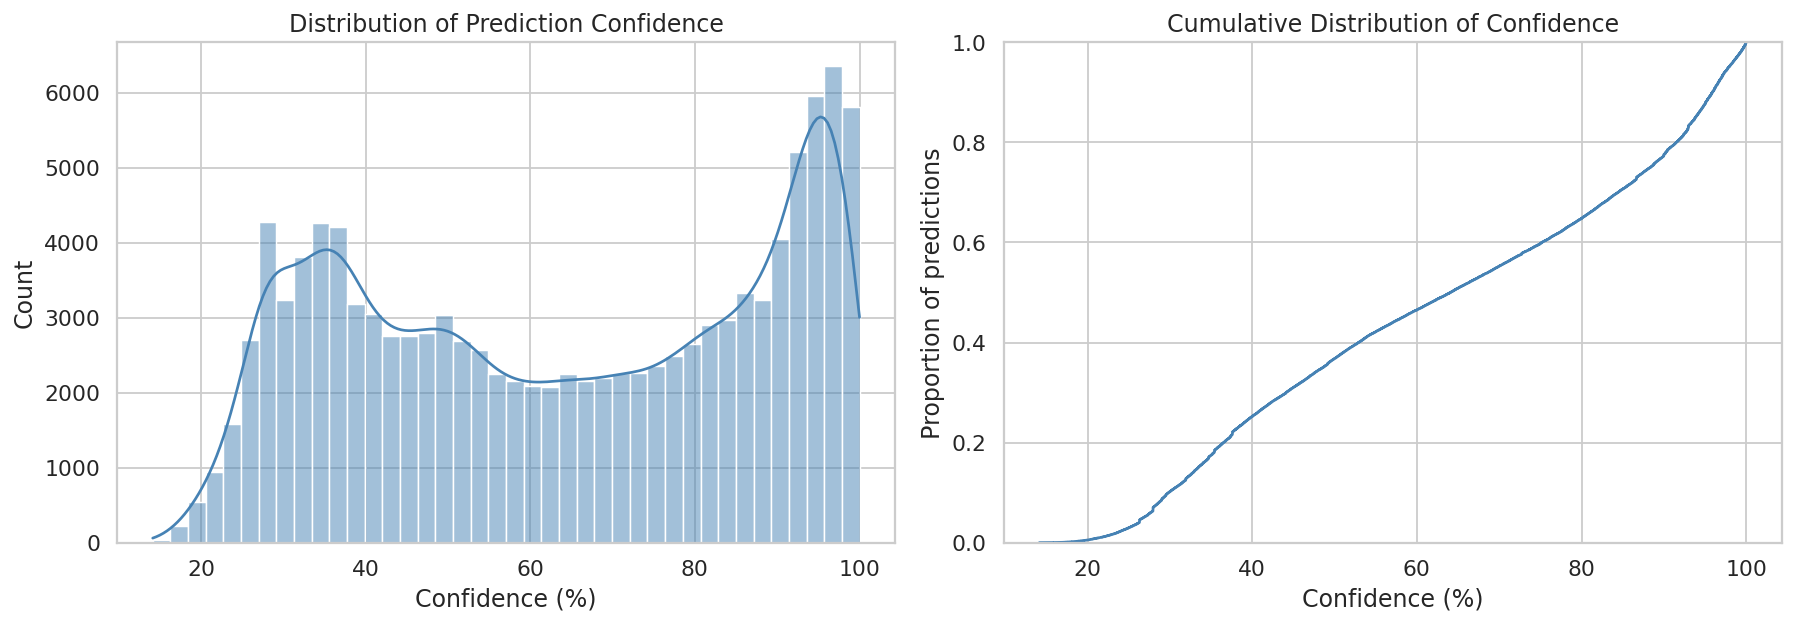

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['confidence_pct'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Prediction Confidence')
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Count')

sns.ecdfplot(df['confidence_pct'], ax=axes[1], color='steelblue')
axes[1].set_title('Cumulative Distribution of Confidence')
axes[1].set_xlabel('Confidence (%)')
axes[1].set_ylabel('Proportion of predictions')

plt.tight_layout()
plt.show()

In [5]:
# Rough confidence buckets, useful for a quick read on how much of the dataset is shaky
bins = [0, 25, 50, 75, 90, 100.01]
labels = ['0-25', '25-50', '50-75', '75-90', '90-100']
df['confidence_bucket'] = pd.cut(df['confidence_pct'], bins=bins, labels=labels, right=False)

bucket_counts = df['confidence_bucket'].value_counts().reindex(labels)
bucket_pct = (bucket_counts / len(df) * 100).round(1)

summary = pd.DataFrame({'count': bucket_counts, 'pct_of_total': bucket_pct})
summary

,count,pct_of_total
confidence_bucket,,
0-25,3416,3.0
25-50,39098,33.8
50-75,26592,23.0
75-90,20526,17.8
90-100,25988,22.5


## 3. Confidence by Predicted Tag

This is the core question: which tags does the model predict with high confidence, and which ones does it hedge on. Low average confidence within a tag suggests that tag is harder to distinguish from the others, either because the vocabulary overlaps with a neighboring tag or the untagged population looks different from what the model trained on.

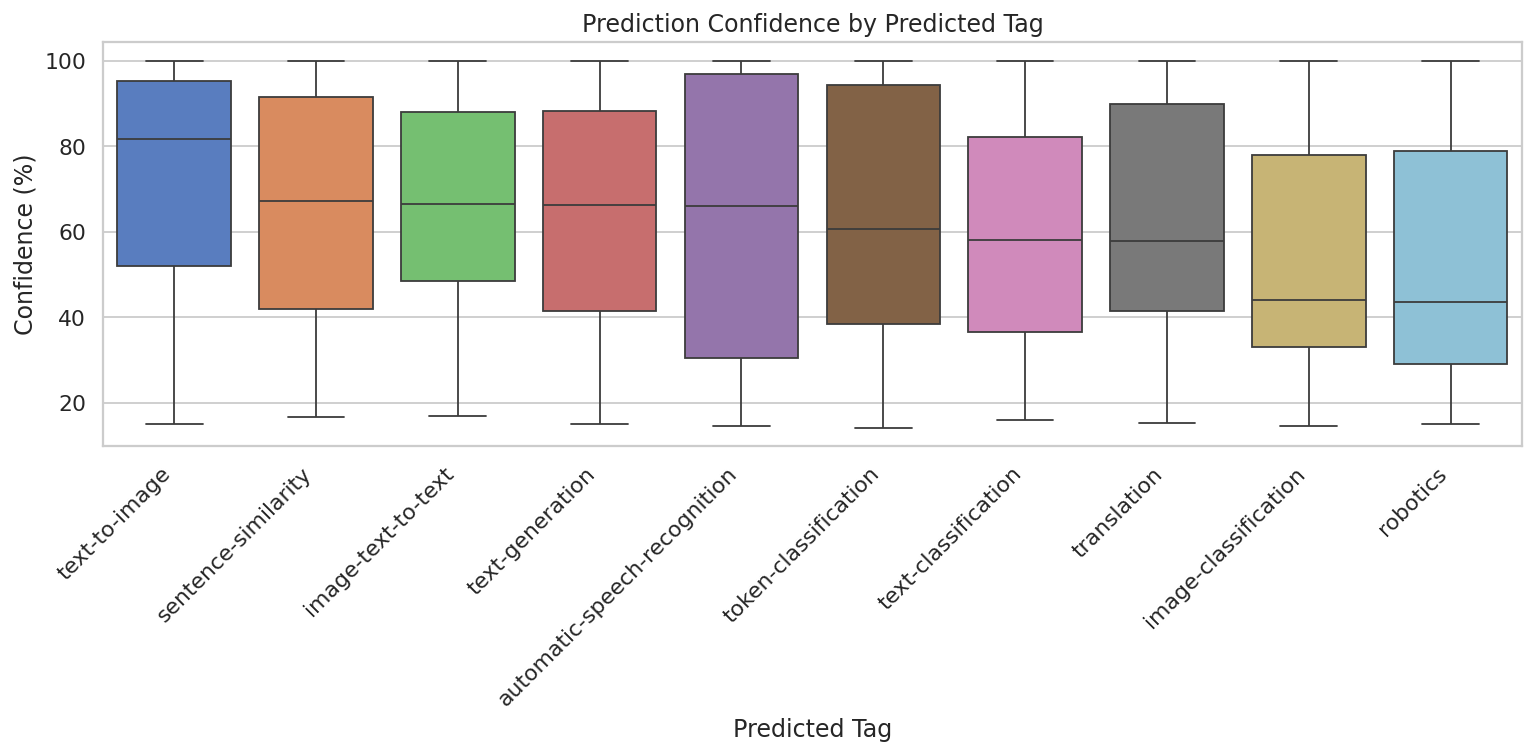

In [6]:
tag_order = df.groupby('predicted_tag')['confidence_pct'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='predicted_tag', y='confidence_pct', order=tag_order, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Prediction Confidence by Predicted Tag')
plt.xlabel('Predicted Tag')
plt.ylabel('Confidence (%)')
plt.tight_layout()
plt.show()

In [7]:
tag_confidence = df.groupby('predicted_tag')['confidence_pct'].agg(
    n='count',
    mean_confidence='mean',
    median_confidence='median',
    std_confidence='std',
    pct_below_50=lambda x: (x < 50).mean() * 100
).round(2).sort_values('mean_confidence', ascending=False)

tag_confidence

,n,mean_confidence,median_confidence,std_confidence,pct_below_50
predicted_tag,,,,,
text-to-image,5160,73.07,81.61,24.70,23.57
image-text-to-text,12758,66.09,66.50,22.57,28.07
sentence-similarity,1198,66.09,67.17,25.28,33.97
text-generation,70027,64.57,66.34,24.11,34.93
automatic-speech-recognition,3809,64.25,66.12,29.86,39.75
token-classification,1097,63.21,60.61,27.97,41.57
translation,1016,62.57,57.91,25.85,40.35
text-classification,7710,59.92,58.03,25.05,41.37
image-classification,8163,54.43,44.09,25.79,55.95


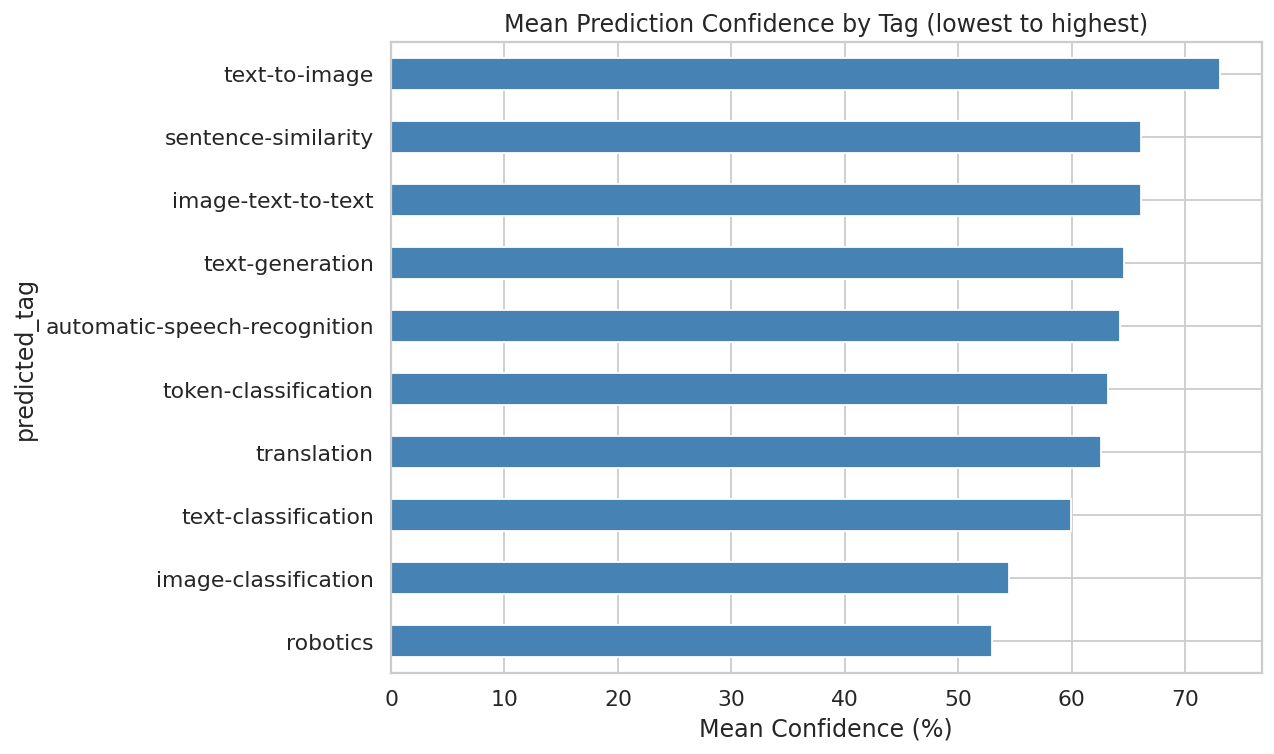

Highest average confidence: text-to-image
Lowest average confidence: robotics


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
tag_confidence['mean_confidence'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean Confidence (%)')
ax.set_title('Mean Prediction Confidence by Tag (lowest to highest)')
plt.tight_layout()
plt.show()

print('Highest average confidence:', tag_confidence.index[0])
print('Lowest average confidence:', tag_confidence.index[-1])

## 4. Predicted Tag Counts vs Training Distribution

If a tag is heavily over-represented in the predictions relative to how it showed up in training, that can be a sign the model defaults to it when unsure, a common pattern for a dominant class like `text-generation`. Comparing counts here flags tags worth a second look even if their confidence looks fine on average.

In [9]:
pred_counts = df['predicted_tag'].value_counts()
pred_pct = (pred_counts / len(df) * 100).round(2)

pred_summary = pd.DataFrame({'predicted_count': pred_counts, 'predicted_pct': pred_pct})
pred_summary

,predicted_count,predicted_pct
predicted_tag,,
text-generation,70027,60.57
image-text-to-text,12758,11.03
image-classification,8163,7.06
text-classification,7710,6.67
text-to-image,5160,4.46
robotics,4682,4.05
automatic-speech-recognition,3809,3.29
sentence-similarity,1198,1.04
token-classification,1097,0.95


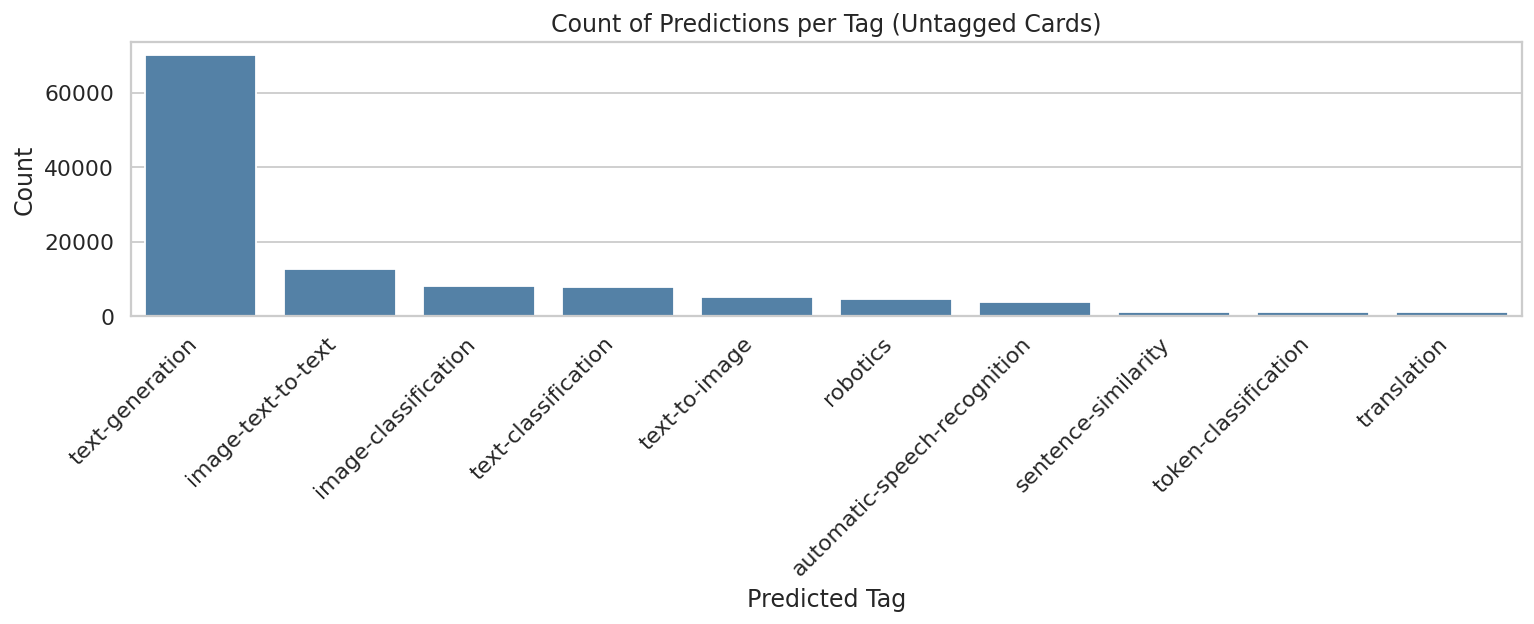

In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(x=pred_counts.index, y=pred_counts.values, order=pred_counts.index, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Count of Predictions per Tag (Untagged Cards)')
plt.xlabel('Predicted Tag')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

If you want a direct side-by-side against the training class distribution, load `train_df.parquet` and compare `train_df['pipeline_tag'].value_counts(normalize=True)` against `pred_pct` above. Left as an optional cell below in case the file isn't loaded yet.

In [11]:
# Optional: compare against training distribution, uncomment to run
# train_df = pd.read_parquet(f'{DRIVE_DIR}/train_df.parquet')
# train_pct = (train_df['pipeline_tag'].value_counts(normalize=True) * 100).round(2)
#
# compare = pd.DataFrame({
#     'train_pct': train_pct,
#     'untagged_pred_pct': pred_pct
# }).fillna(0)
# compare['diff'] = (compare['untagged_pred_pct'] - compare['train_pct']).round(2)
# compare.sort_values('diff', ascending=False)

## 5. Lowest Confidence Predictions per Tag

The rows most worth a manual look, the ones the model itself is least sure about, broken out by tag so you can see whether the weak predictions cluster in a few categories or are spread evenly.

In [12]:
n_lowest = 5

lowest_by_tag = (
    df.sort_values('confidence_pct')
    .groupby('predicted_tag', group_keys=True)
    .head(n_lowest)
    [['modelId', 'predicted_tag', 'confidence_pct']]
    .sort_values(['predicted_tag', 'confidence_pct'])
)

lowest_by_tag

,modelId,predicted_tag,confidence_pct
76765,cplusx/MEMO_onnx_runtime,automatic-speech-recognition,14.47
12980,Justinthyy/SynGasOBDFuelSaverCa,automatic-speech-recognition,14.91
68308,haoxiangsnr/IntelNeuromorphicDNSChallenge,automatic-speech-recognition,17.39
34361,mlx-community/RestoreFormerPlusPlus-fp32,automatic-speech-recognition,17.41
24186,PalatineVision/palatine-ffmpeg,automatic-speech-recognition,17.67
27211,uyen1109/eth-fraud-gnn-uyenuyen-v1,image-classification,14.65
70114,adsajdjs/DeepField_PlayerDigit_Number_Analysis...,image-classification,15.11
33207,aarnachauhan/cyberbullying-detection-model,image-classification,16.04
102684,Adeely93/SafeR_CLIP,image-classification,16.15
67695,nvan13/HRA,image-classification,16.22


In [13]:
# Overall lowest confidence predictions across the whole dataset, regardless of tag
df.sort_values('confidence_pct').head(15)[['modelId', 'predicted_tag', 'confidence_pct', 'card_text_clean']]

,modelId,predicted_tag,confidence_pct,card_text_clean
103284,manak0/Detect-number-plates-1-0-winner,token-classification,14.14,detect number plates winner published winning ...
76765,cplusx/MEMO_onnx_runtime,automatic-speech-recognition,14.47,memo onnx runtime models this repository store...
27211,uyen1109/eth-fraud-gnn-uyenuyen-v1,image-classification,14.65,ethereum fraud gnn gradio demo v demo tra c u ...
54920,jasonmusespresso/glove-2024-wikigiga-100d,token-classification,14.81,glove wikigigaword d this is a mirror of the g...
82049,medicenjona1/jona,token-classification,14.87,medicenjona jona cloned voice model este es un...
54250,Rongbachkincom/Soicauxsmb,text-generation,14.91,p data path to node p p data path to node b da...
12980,Justinthyy/SynGasOBDFuelSaverCa,automatic-speech-recognition,14.91,p span style font family overpass segoe ui rob...
103315,hacnho/openvino-save-model-scanner-bypass-poc,text-generation,15.00,pickle scanner bypass via openvino save model ...
6482,airg/unet-efficientnet-b7-ltfl-mmgab-100ep-1wi...,text-to-image,15.05,u net generally conforming to the current ftw ...
23240,Patoni31/ll3,text-generation,15.07,digitalna platforma za moderno iskustvo igranj...


## 6. Text Length vs Confidence

Checking whether card length relates to confidence at all. If short cards systematically get lower confidence, that points to a data problem (not enough signal in a short card) rather than a modeling problem.

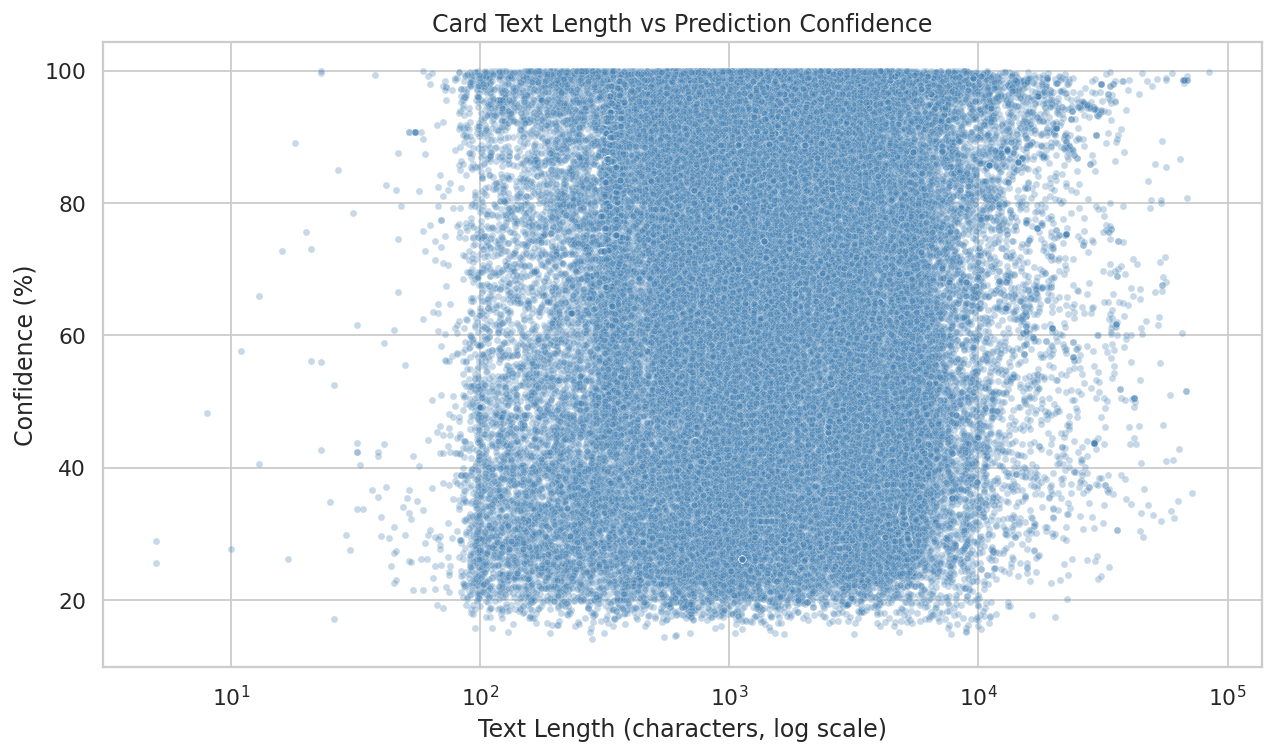

Correlation (text length vs confidence): -0.09


In [14]:
df['text_len'] = df['card_text_clean'].str.len()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='text_len', y='confidence_pct', alpha=0.3, s=15, color='steelblue')
plt.xscale('log')
plt.title('Card Text Length vs Prediction Confidence')
plt.xlabel('Text Length (characters, log scale)')
plt.ylabel('Confidence (%)')
plt.tight_layout()
plt.show()

print('Correlation (text length vs confidence):', df['text_len'].corr(df['confidence_pct']).round(3))

## 7. Summary Table

A single table pulling together tag-level confidence and volume, sorted from least to most confident. This is the table worth screenshotting for the writeup.

In [15]:
summary_table = tag_confidence.join(pred_summary)
summary_table = summary_table[['n', 'predicted_pct', 'mean_confidence', 'median_confidence', 'std_confidence', 'pct_below_50']]
summary_table = summary_table.sort_values('mean_confidence')

summary_table

,n,predicted_pct,mean_confidence,median_confidence,std_confidence,pct_below_50
predicted_tag,,,,,,
robotics,4682,4.05,52.95,43.52,27.05,57.95
image-classification,8163,7.06,54.43,44.09,25.79,55.95
text-classification,7710,6.67,59.92,58.03,25.05,41.37
translation,1016,0.88,62.57,57.91,25.85,40.35
token-classification,1097,0.95,63.21,60.61,27.97,41.57
automatic-speech-recognition,3809,3.29,64.25,66.12,29.86,39.75
text-generation,70027,60.57,64.57,66.34,24.11,34.93
image-text-to-text,12758,11.03,66.09,66.50,22.57,28.07
sentence-similarity,1198,1.04,66.09,67.17,25.28,33.97


**Reading this table:**

- Tags near the top have the lowest mean confidence, these are the ones the baseline finds hardest to call on this unseen, previously-untagged population.
- `pct_below_50` flags tags where a meaningful share of predictions are close to a coin flip, worth flagging as unreliable even if the mean looks okay.
- `predicted_pct` next to training distribution (Section 4) tells you whether a tag is over-predicted, which combined with low confidence usually means the model is defaulting to it rather than confidently recognizing it.